# EconAgent — Análisis de resultados (Nova Pro / Bedrock)

Análisis de la corrida con `us.amazon.nova-pro-v1:0` vía Bedrock (`ECON_BACKEND=bedrock`), 100 agentes, 240 meses.

Mismo formato que `analysis_novalite_100agents_240months.ipynb` (corrida con Nova Lite) y `analysis.ipynb` (corrida original con gpt-3.5-turbo-0613), para poder comparar resultados entre modelos. Los archivos en `data/` son todos generados por la corrida, salvo `profiles.json` que se genera al inicio.

In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (12, 4)

# Examinamos los archivos

 Descripción de Archivos

| Archivo / Carpeta | Descripción |
| :--- | :--- |
| `env_6.pkl`, `env_12.pkl` | El objeto `env` completo (estado de Foundation) serializado en el paso 6 y 12. |
| `obs_6.pkl`, `obs_12.pkl` | La observación devuelta por el `env` en ese paso. |
| `actions_6.pkl`, `actions_12.pkl` | Las acciones `[work, consumption]` decodificadas del JSON del LLM para cada agente. |
| `dialog_6.pkl`, `dialog_12.pkl` | La cola corta de diálogo (`dialog_queue`, `maxlen=3`) que se manda como contexto al LLM en cada llamada. |
| `dialog4ref_6.pkl`, `dialog4ref_12.pkl` | La cola larga de diálogo (`maxlen=7`) que alimenta las reflexiones trimestrales. |
| `dense_log.pkl`, `dense_log_6.pkl`, `dense_log_12.pkl` | El log denso de Foundation: histórico completo de estados/acciones/recompensas de la simulación, paso a paso (esto es lo que analiza este notebook). |
| `dialogs/` | Carpeta con un archivo de texto por agente (nombre del agente = nombre del archivo), con el historial completo de la conversación en texto plano — útil para leer "a mano" qué le contestó el LLM a cada agente mes a mes. |

**Nota sobre esta corrida**: a diferencia de la corrida de Nova Lite (donde el nombre de carpeta no incluía el modelo y por eso convivía con la de gpt-3.5 bajo el mismo nombre), esta carpeta sí incluye el modelo en el nombre (`gpt-bedrock-us.amazon.nova-pro-v1-0-3-...`), así que no hay riesgo de pisado con otras corridas.

**Caveat encontrado al inspeccionar `dialogs/`**: la carpeta tiene **135 archivos**, pero la corrida tiene **100 agentes**. Verificado contra los nombres de agente en `dense_log['states'][-1]`: los 100 nombres de la corrida actual están todos presentes, y sobran **35 archivos** que no corresponden a ningún agente de esta corrida — son residuo de una corrida anterior con nombres distintos que reusó la misma carpeta de `dialogs/` (que es aditiva, no se limpia entre corridas). La sección 13 de este notebook filtra explícitamente por los 100 nombres reales antes de parsear, para no contaminar el análisis con esos 35 archivos viejos.

## 1. Cargar resultados

In [2]:
# Listá las simulaciones disponibles
data_dir = Path('data')
runs = sorted([p for p in data_dir.iterdir() if p.is_dir()])
for i, r in enumerate(runs):
    print(f'[{i}] {r.name}')

[0] gpt-3-noperception-reflection-1-100agents-120months
[1] gpt-3-noperception-reflection-1-100agents-240months
[2] gpt-3-noperception-reflection-1-100agents-48months
[3] gpt-3-noperception-reflection-1-100agents-54months
[4] gpt-3-noperception-reflection-1-40agents-48months
[5] gpt-bedrock-us.amazon.nova-pro-v1-0-3-noperception-reflection-1-100agents-240months
[6] gpt-bedrock-us.amazon.nova-pro-v1-0-3-noperception-reflection-1-100agents-240months-backup


In [3]:
# Esta corrida es Nova Pro vía Bedrock (100 agentes, 240 meses, dialog_len=3)
RUN_NAME = 'gpt-bedrock-us.amazon.nova-pro-v1-0-3-noperception-reflection-1-100agents-240months'
run_path = next(r for r in runs if r.name == RUN_NAME)
print(f'Analizando: {run_path.name}')

with open(run_path / 'dense_log.pkl', 'rb') as f:
    log = pkl.load(f)

print('\nClaves disponibles en dense_log:')
print(list(log.keys()))

Analizando: gpt-bedrock-us.amazon.nova-pro-v1-0-3-noperception-reflection-1-100agents-240months

Claves disponibles en dense_log:
['world', 'states', 'actions', 'rewards', 'PeriodicTax']


**Metadata de la corrida**:
- Backend: `bedrock` — modelo: `us.amazon.nova-pro-v1:0`
- 100 agentes, 240 meses, `dialog_len=3`

**⚠️ Mismo bug de pricing que en la corrida de Nova Lite sigue presente**: `.env` tiene `PRICE_INPUT_PER_1M=3` / `PRICE_OUTPUT_PER_1M=15` (precio de Claude Sonnet 4.6), no el de Nova Pro (que en Bedrock ronda $0.80 / $3.20 por 1M — unas 4-5x más barato). No se capturó la transcripción de consola de esta corrida, así que no reportamos acá un costo total — si la tenés, hay que corregirla con el mismo factor antes de comparar costos entre modelos.


### archivo actions_6.pkl muestra los agentes y el gobierno (p de planner) con las decisiones de trabajo/consumo del mes 6.


In [4]:
from pprint import pprint

actions_6_path = run_path / 'actions_6.pkl'

if actions_6_path.exists():
    with open(actions_6_path, 'rb') as f:
        actions_6 = pkl.load(f)
    print(f'Archivo cargado: {actions_6_path.name}')
else:
    actions_6 = log.get('actions_6', None)
    print('No se encontró actions_6.pkl; usando log["actions_6"] si existe.')

print('Tipo:', type(actions_6))

# Mostramos las decisiones de los agentes (acciones) para el mes 6 excluyendo el planner (P)
for key,value in actions_6.items():
    if key!='p':
        print(f'Key: {key}, Work: {value[0]}, Consumption: {value[1] if len(value) > 1 else "N/A"}')


Archivo cargado: actions_6.pkl
Tipo: <class 'dict'>
Key: 0, Work: 1, Consumption: 49.0
Key: 1, Work: 1, Consumption: 49.0
Key: 2, Work: 1, Consumption: 27.0
Key: 3, Work: 1, Consumption: 25.0
Key: 4, Work: 1, Consumption: 32.0
Key: 5, Work: 1, Consumption: 8.0
Key: 6, Work: 1, Consumption: 7.000000000000001
Key: 7, Work: 1, Consumption: 4.5
Key: 8, Work: 1, Consumption: 8.0
Key: 9, Work: 1, Consumption: 6.0
Key: 10, Work: 1, Consumption: 10.0
Key: 11, Work: 1, Consumption: 28.000000000000004
Key: 12, Work: 1, Consumption: 7.000000000000001
Key: 13, Work: 0, Consumption: 7.000000000000001
Key: 14, Work: 1, Consumption: 6.0
Key: 15, Work: 1, Consumption: 12.0
Key: 16, Work: 1, Consumption: 9.0
Key: 17, Work: 1, Consumption: 7.000000000000001
Key: 18, Work: 1, Consumption: 13.0
Key: 19, Work: 1, Consumption: 6.0
Key: 20, Work: 1, Consumption: 6.0
Key: 21, Work: 1, Consumption: 7.000000000000001
Key: 22, Work: 1, Consumption: 6.0
Key: 23, Work: 1, Consumption: 6.0
Key: 24, Work: 0, Consump

### 1. El LLM devuelve un porcentaje (0 a 1)
El prompt le pide al LLM: "'consumption' (a value between 0 and 1 with intervals of 0.02)" — es decir, algo como 0.5 = "quiero gastar el 50% de mis ahorros+ingreso disponible en bienes esenciales".

### 2. simulate.py convierte ese porcentaje en un índice discreto

extracted_actions[1] /= 0.02
(simulate.py:138)

Si el LLM contestó consumption = 0.5, esto hace 0.5 / 0.02 = 25. Ese 25 es el número que terminás viendo guardado en actions_6.pkl. No es "25 dólares" ni "25%" — es un índice de acción discreta dentro de una grilla de 50 posiciones (n_actions = 1.0/0.02 = 50, simple_consumption.py:35).

### 3. Foundation vuelve a convertir ese índice en tasa real
Cuando Foundation ejecuta el step, el componente SimpleConsumption toma esa acción (action=25) y hace la operación inversa:


consumption_rate = action * self.consumption_rate_step   # 25 * 0.02 = 0.5
(simple_consumption.py:84)

Es decir: 25 × 0.02 = 0.5 → 50% de la tasa de consumo, que es exactamente el mismo porcentaje que el LLM dijo originalmente en el prompt.

Por qué existe este ida y vuelta
Foundation (heredado del paper RL original) espera acciones discretas porque las redes de política PPO tienen una cabeza de clasificación (softmax sobre 50 categorías), no un valor continuo. El LLM en cambio razona más naturalmente en porcentajes continuos (0 a 1). Entonces:

LLM → índice: se divide por 0.02 para "encajar" la respuesta continua del LLM en la grilla discreta de 50 acciones que espera el motor de Foundation.
índice → efecto real: Foundation multiplica por 0.02 de vuelta para recuperar la tasa real y calcular cuánto dinero gasta el agente ese mes.
En resumen: el valor guardado en el .pkl es un artefacto de codificación intermedio (el índice de acción), y su significado económico real es simplemente índice × 0.02 = proporción gastada ese mes.

## 2. Extraer series de tiempo

In [5]:
type(log)
# mostrar los primeros 5 elementos de cada clave en log

for key in log.keys():
    print(f'Key: {key}, First 5 elements: {log[key][:5] if isinstance(log[key], list) else log[key]}')

#['world', 'states', 'actions', 'rewards', 'PeriodicTax']

world_key=log['world'][0]

print(world_key)
states_key=log['states'][0]
print(states_key)


Key: world, First 5 elements: [{'Price': np.float64(135.98578564462375), '#Products': 0}, {'Price': np.float64(124.0518076387751), '#Products': np.float64(15135.657291917356)}, {'Price': np.float64(116.55811976169969), '#Products': np.float64(28553.54146801093)}, {'Price': np.float64(106.33247424083666), '#Products': np.float64(40228.93240410085)}, {'Price': np.float64(105.37390808601474), '#Products': np.float64(49565.241966762)}]
Key: states, First 5 elements: [{'0': {'loc': [-1, -1], 'inventory': {'Coin': 0, 'Products': 0}, 'escrow': {'Coin': 0, 'Products': 0}, 'consumption': {'Coin': 0, 'Products': 0}, 'investment': {'Coin': 0, 'Products': 0}, 'saving': {'Coin': 0, 'Products': 0}, 'income': {'Coin': 0, 'Products': 0}, 'endogenous': {'Consumption Rate': 0.5, 'Investment Rate': 0.5, 'Labor': 0, 'Saving Rate': 0, 'age': 49, 'name': np.str_('Angela Garcia'), 'city': 'New York City, New York', 'job': 'Unemployment', 'offer': np.str_('House Cleaner')}, 'skill': np.float64(2.2060193914332

In [6]:
T = len(log['states'])
n_agents = len([k for k in log['states'][0].keys() if k != 'p'])
print(f'Pasos: {T}   Agentes: {n_agents}')

# --- Macroeconómicos (world) ---
world_df = pd.DataFrame(log['world'])
world_df.index.name = 'step'

# --- Estados de agentes ---
wealth    = np.array([[log['states'][t][str(i)]['inventory']['Coin']  for i in range(n_agents)] for t in range(T)])
income    = np.array([[log['states'][t][str(i)].get('income', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
skill     = np.array([[log['states'][t][str(i)]['skill']               for i in range(n_agents)] for t in range(T)])

print('world_df columnas:', list(world_df.columns))

Pasos: 241   Agentes: 100
world_df columnas: ['Price', '#Products', 'Interest Rate', 'Unemployment Rate', 'Real GDP', 'Nominal GDP', 'Price Inflation', 'Unemployment Rate Growth', 'Wage Inflation', 'Nominal GDP Growth', 'Real GDP Growth']


## 3. Indicadores macroeconómicos

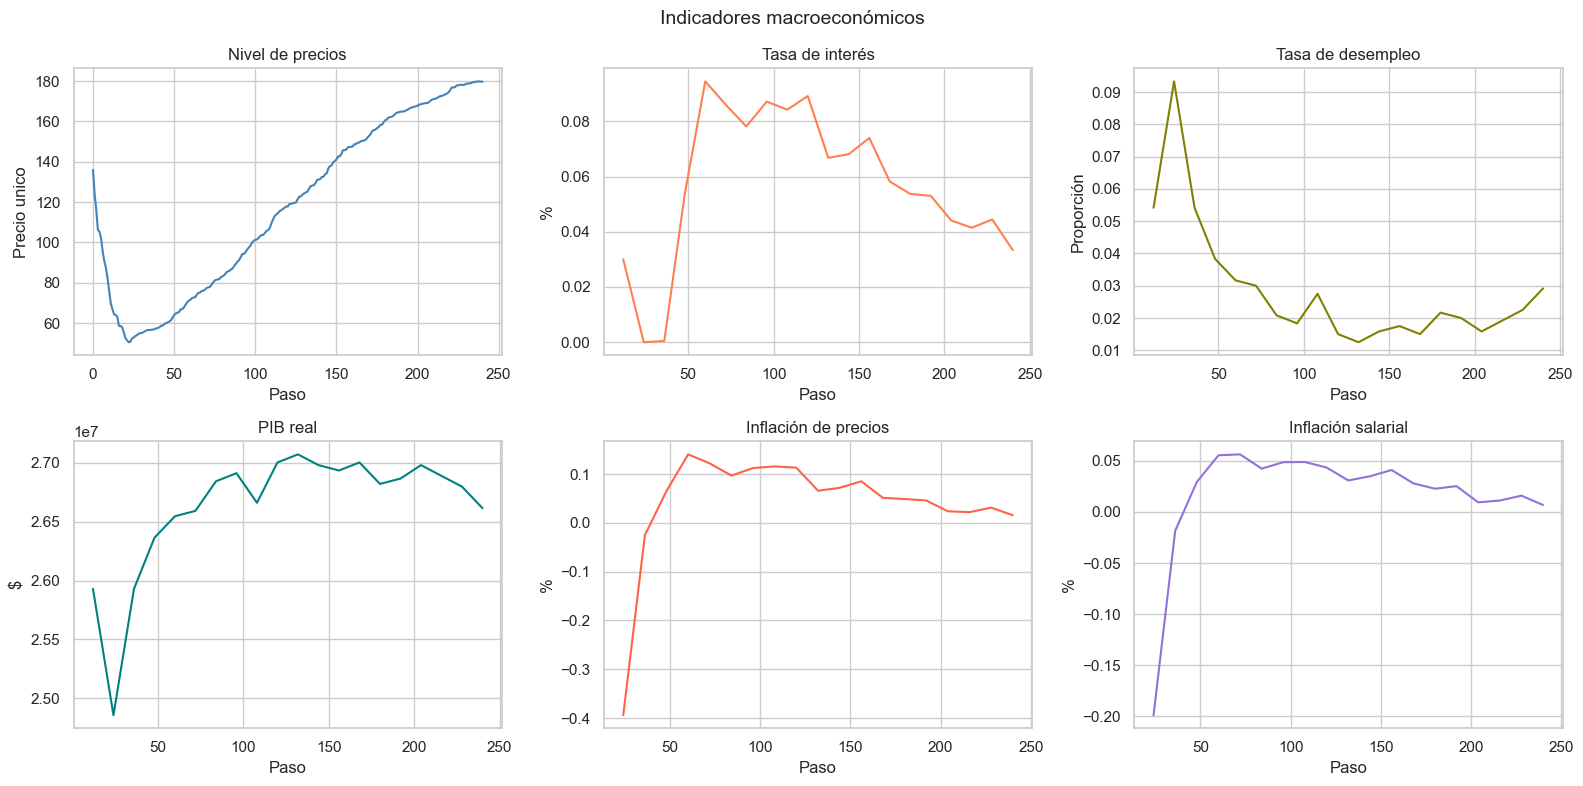

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Indicadores macroeconómicos', fontsize=14)
steps = range(T)

def plot_series(ax, series, title, ylabel, color='steelblue'):
    clean = series.dropna()
    ax.plot(clean.index, clean.values, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Paso')

plot_series(axes[0,0], world_df['Price'],           'Nivel de precios',      'Precio unico')
plot_series(axes[0,1], world_df.get('Interest Rate', pd.Series(dtype=float)), 'Tasa de interés', '%', color='coral')
plot_series(axes[0,2], world_df.get('Unemployment Rate', pd.Series(dtype=float)), 'Tasa de desempleo', 'Proporción', color='olive')
plot_series(axes[1,0], world_df.get('Real GDP', pd.Series(dtype=float)),       'PIB real',      '$', color='teal')
plot_series(axes[1,1], world_df.get('Price Inflation', pd.Series(dtype=float)), 'Inflación de precios', '%', color='tomato')
plot_series(axes[1,2], world_df.get('Wage Inflation', pd.Series(dtype=float)),  'Inflación salarial',  '%', color='mediumpurple')

plt.tight_layout()
plt.show()

## 4. Distribución de riqueza

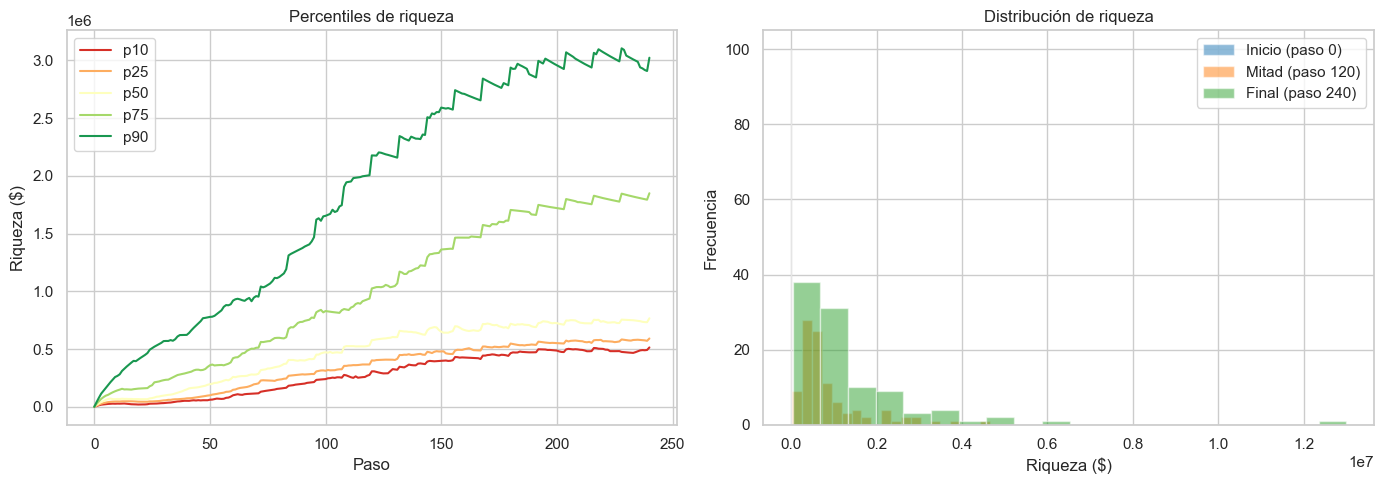

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Percentiles de riqueza a lo largo del tiempo
ax = axes[0]
quantiles = [10, 25, 50, 75, 90]
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(quantiles)))
for q, c in zip(quantiles, colors):
    ax.plot(np.percentile(wealth, q, axis=1), label=f'p{q}', color=c)
ax.set_title('Percentiles de riqueza')
ax.set_xlabel('Paso')
ax.set_ylabel('Riqueza ($)')
ax.legend()

# Distribución al inicio, mitad y final
ax = axes[1]
checkpoints = [0, T//2, T-1]
labels = ['Inicio', 'Mitad', 'Final']
for cp, label in zip(checkpoints, labels):
    ax.hist(wealth[cp], bins=20, alpha=0.5, label=f'{label} (paso {cp})')
ax.set_title('Distribución de riqueza')
ax.set_xlabel('Riqueza ($)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Coeficiente de Gini

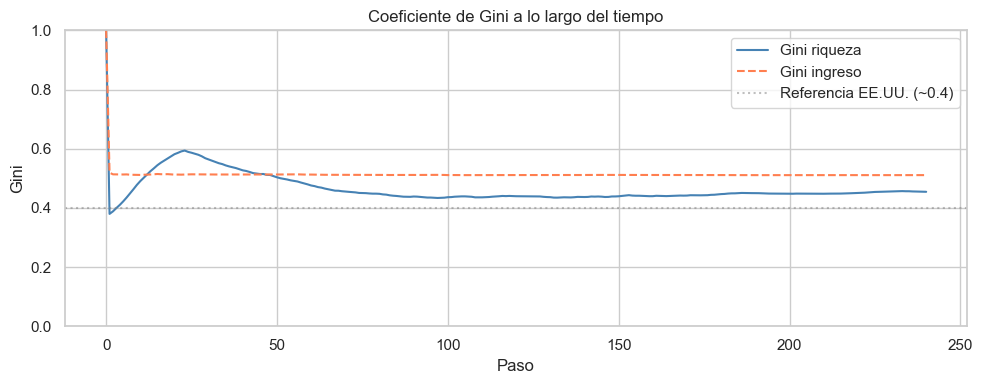

Gini riqueza  — inicio: 1.000  |  final: 0.454
Gini ingreso  — inicio: 1.000  |  final: 0.511


In [9]:
def gini(x):
    x = np.sort(np.abs(x))
    n = len(x)
    return 1 - (2 / (n + 1)) * np.sum(np.cumsum(x) / (np.sum(x) + 1e-10))

gini_wealth = [gini(wealth[t]) for t in range(T)]
gini_income = [gini(income[t]) for t in range(T)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gini_wealth, label='Gini riqueza', color='steelblue')
ax.plot(gini_income, label='Gini ingreso', color='coral', linestyle='--')
ax.set_ylim(0, 1)
ax.set_title('Coeficiente de Gini a lo largo del tiempo')
ax.set_xlabel('Paso')
ax.set_ylabel('Gini')
ax.axhline(0.4, color='gray', linestyle=':', alpha=0.5, label='Referencia EE.UU. (~0.4)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Gini riqueza  — inicio: {gini_wealth[0]:.3f}  |  final: {gini_wealth[-1]:.3f}')
print(f'Gini ingreso  — inicio: {gini_income[0]:.3f}  |  final: {gini_income[-1]:.3f}')

## 6. Curva de Lorenz (inicio vs final)

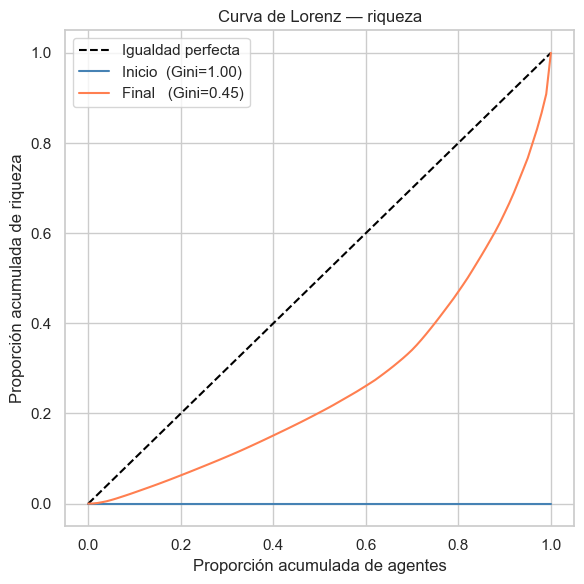

In [10]:
def lorenz(x):
    x = np.sort(np.abs(x))
    cum = np.cumsum(x) / (np.sum(x) + 1e-10)
    return np.concatenate([[0], cum])

fig, ax = plt.subplots(figsize=(6, 6))
pop = np.linspace(0, 1, n_agents + 1)

ax.plot([0, 1], [0, 1], 'k--', label='Igualdad perfecta')
ax.plot(pop, lorenz(wealth[0]),   label=f'Inicio  (Gini={gini_wealth[0]:.2f})',  color='steelblue')
ax.plot(pop, lorenz(wealth[-1]),  label=f'Final   (Gini={gini_wealth[-1]:.2f})', color='coral')

ax.set_title('Curva de Lorenz — riqueza')
ax.set_xlabel('Proporción acumulada de agentes')
ax.set_ylabel('Proporción acumulada de riqueza')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Actividad laboral y consumo

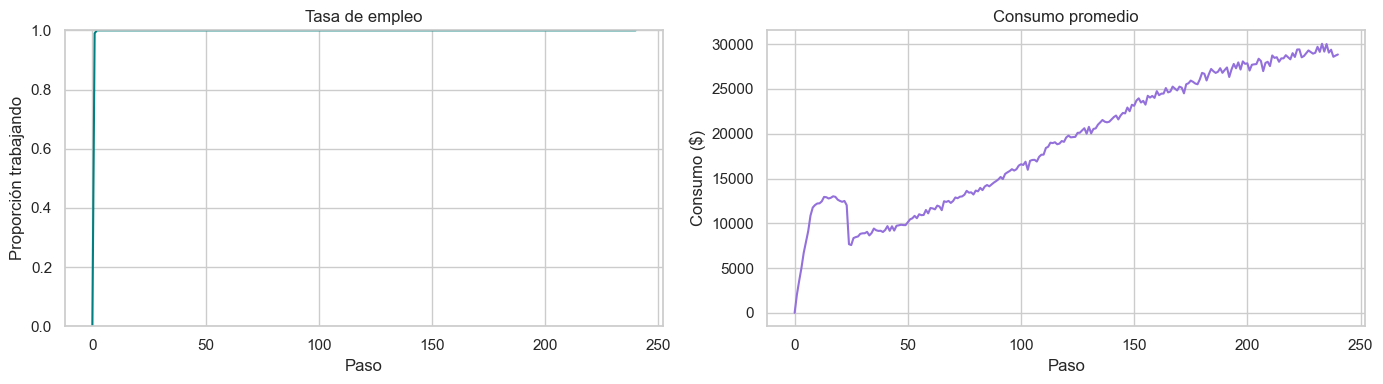

In [11]:
# Tasa de empleo: proporción de agentes que trabajaron en cada paso
if 'SimpleLabor' in log:
    labor_log = log['SimpleLabor']
    labor_rate = [np.mean([a > 0 for a in step.values()]) if isinstance(step, dict) else np.mean(np.array(step) > 0) for step in labor_log]
else:
    labor_rate = [np.mean(income[t] > 0) for t in range(T)]

# Consumo promedio
consumption = np.array([[log['states'][t][str(i)].get('consumption', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
mean_consumption = consumption.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(labor_rate, color='teal')
axes[0].set_ylim(0, 1)
axes[0].set_title('Tasa de empleo')
axes[0].set_xlabel('Paso')
axes[0].set_ylabel('Proporción trabajando')

axes[1].plot(mean_consumption, color='mediumpurple')
axes[1].set_title('Consumo promedio')
axes[1].set_xlabel('Paso')
axes[1].set_ylabel('Consumo ($)')

plt.tight_layout()
plt.show()

## 8. Impuestos y redistribución

In [12]:
tax_key = [k for k in log.keys() if 'BracketTax' in k and 'tax_paid' in k]
lump_key = [k for k in log.keys() if 'BracketTax' in k and 'lump_sum' in k]

if tax_key and lump_key:
    tax_data  = np.array(log[tax_key[0]])   # shape (T, n_agents) or similar
    lump_data = np.array(log[lump_key[0]])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(tax_data.mean(axis=-1) if tax_data.ndim > 1 else tax_data, color='tomato')
    axes[0].set_title('Impuesto promedio pagado')
    axes[0].set_xlabel('Paso')
    axes[0].set_ylabel('$ impuesto')

    axes[1].plot(lump_data.mean(axis=-1) if lump_data.ndim > 1 else lump_data, color='seagreen')
    axes[1].set_title('Lump-sum redistribuido (promedio)')
    axes[1].set_xlabel('Paso')
    axes[1].set_ylabel('$ recibido')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron datos de impuestos en el dense_log.')
    print('Claves disponibles:', [k for k in log.keys() if 'Tax' in k or 'tax' in k])

No se encontraron datos de impuestos en el dense_log.
Claves disponibles: ['PeriodicTax']


## 9. Resumen estadístico

In [13]:
summary = pd.DataFrame({
    'Riqueza media':       wealth.mean(axis=1),
    'Riqueza mediana':     np.median(wealth, axis=1),
    'Riqueza std':         wealth.std(axis=1),
    'Ingreso medio':       income.mean(axis=1),
    'Consumo medio':       mean_consumption,
    'Gini riqueza':        gini_wealth,
    'Gini ingreso':        gini_income,
})

print('=== Estadísticas al INICIO ===')
print(summary.iloc[0].to_string())
print('\n=== Estadísticas al FINAL ===')
print(summary.iloc[-1].to_string())

=== Estadísticas al INICIO ===
Riqueza media      0.0
Riqueza mediana    0.0
Riqueza std        0.0
Ingreso medio      0.0
Consumo medio      0.0
Gini riqueza       1.0
Gini ingreso       1.0

=== Estadísticas al FINAL ===
Riqueza media      1.423616e+06
Riqueza mediana    7.666330e+05
Riqueza std        1.626582e+06
Ingreso medio      2.662375e+04
Consumo medio      2.885320e+04
Gini riqueza       4.544725e-01
Gini ingreso       5.108521e-01


## 10. Curva de Phillips y Ley de Okun (validación vs. el paper)

El paper original usa estas dos regularidades como principal criterio de plausibilidad (Figura 3): correlación negativa entre desempleo e inflación salarial (Phillips) y entre crecimiento del desempleo y crecimiento del PIB real (Okun). Reportan Pearson r=-0.619 (p<0.01) y r=-0.918 (p<0.001) respectivamente para EconAgent con gpt-3.5-turbo-0613, muy superior a los baselines rule-based/RL.

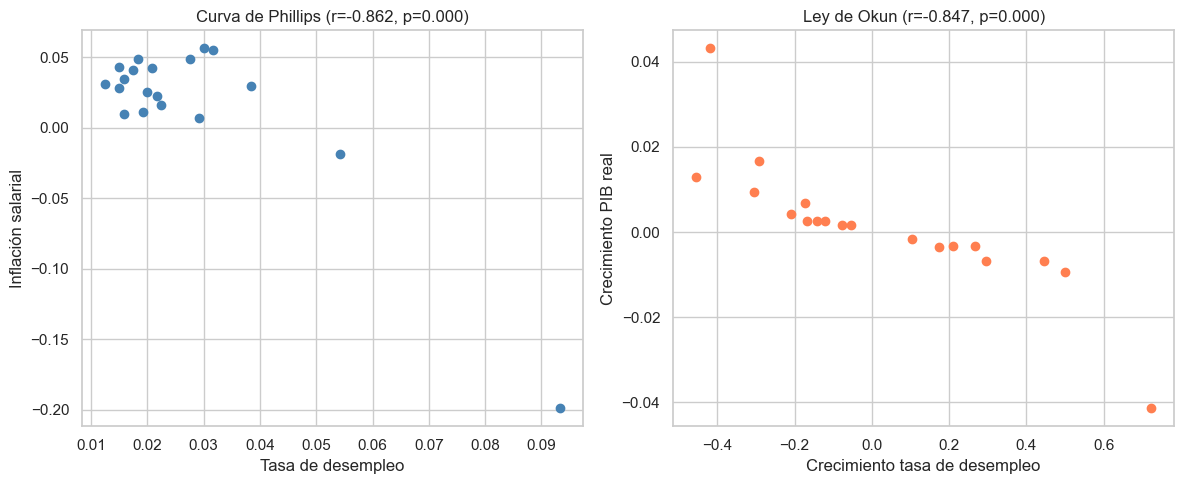

Phillips: r=-0.862  p=0.0000   (paper gpt-3.5: r=-0.619, p<0.01)
Okun:     r=-0.847  p=0.0000   (paper gpt-3.5: r=-0.918, p<0.001)


In [14]:
from scipy.stats import pearsonr

unemp_a = world_df['Unemployment Rate'].dropna()
wage_infl_a = world_df['Wage Inflation'].dropna()
unemp_growth_a = world_df['Unemployment Rate Growth'].dropna()
gdp_growth_a = world_df['Real GDP Growth'].dropna()

# Alinear por índice (mismos steps anuales)
phillips = pd.concat([unemp_a, wage_infl_a], axis=1).dropna()
okun = pd.concat([unemp_growth_a, gdp_growth_a], axis=1).dropna()

r_phillips, p_phillips = pearsonr(phillips.iloc[:,0], phillips.iloc[:,1])
r_okun, p_okun = pearsonr(okun.iloc[:,0], okun.iloc[:,1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(phillips.iloc[:,0], phillips.iloc[:,1], color='steelblue')
axes[0].set_title(f'Curva de Phillips (r={r_phillips:.3f}, p={p_phillips:.3f})')
axes[0].set_xlabel('Tasa de desempleo')
axes[0].set_ylabel('Inflación salarial')

axes[1].scatter(okun.iloc[:,0], okun.iloc[:,1], color='coral')
axes[1].set_title(f"Ley de Okun (r={r_okun:.3f}, p={p_okun:.3f})")
axes[1].set_xlabel('Crecimiento tasa de desempleo')
axes[1].set_ylabel('Crecimiento PIB real')

plt.tight_layout()
plt.show()

print(f'Phillips: r={r_phillips:.3f}  p={p_phillips:.4f}   (paper gpt-3.5: r=-0.619, p<0.01)')
print(f'Okun:     r={r_okun:.3f}  p={p_okun:.4f}   (paper gpt-3.5: r=-0.918, p<0.001)')

### Versión mensual (240 puntos) de la curva de Phillips

La Phillips de arriba usa los ~19-20 puntos **anuales** que loguea Foundation (`Unemployment Rate` / `Wage Inflation`, calculados una vez por año). Acá reconstruimos el equivalente **mes a mes**: desempleo mensual vs. el cambio porcentual mes a mes del salario medio (`skill` promedio de los 100 agentes). Foundation no loguea esta versión mensual — la armamos directo de `log['states']`, así que esta celda no depende de las secciones 12-14 (usa su propia copia de `work_raw` y `mean_skill`).

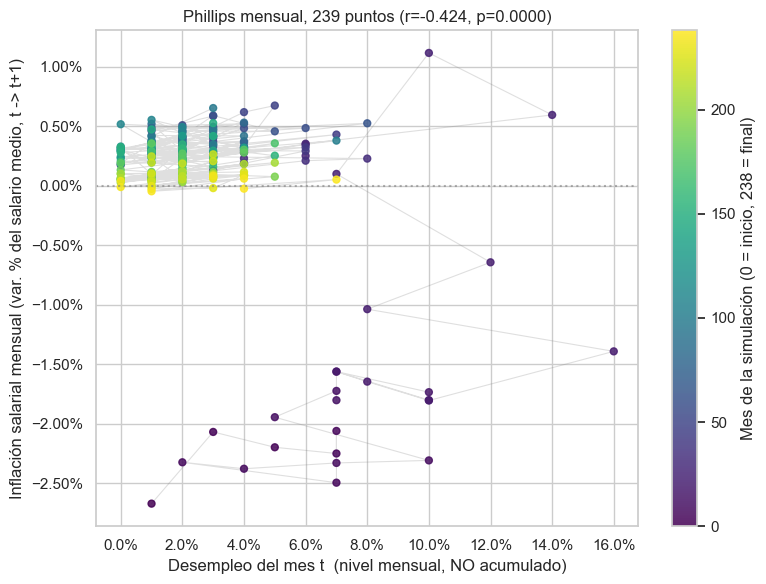

Phillips mensual (239 puntos):  r=-0.424  p=0.0000
Phillips anual (19 puntos, sección 10):    r=-0.862  p=0.0000

Unidades: eje X = nivel de desempleo de ese mes (proporción/%, no acumulado).
          eje Y = variación % del salario medio respecto al mes anterior (tasa mensual, no anualizada, no acumulada).
Color = mes de la simulación (violeta=inicio, amarillo=final); la línea gris conecta los puntos en orden cronológico.


In [15]:
_T_a = len(log['actions'])
_work_raw = np.array([[log['actions'][t][str(i)].get('SimpleLabor', 0) for i in range(n_agents)] for t in range(_T_a)])
_mean_skill = np.array([np.mean([log['states'][t][str(i)]['skill'] for i in range(n_agents)]) for t in range(_T_a)])

_unemp_rate_t = 1 - _work_raw.mean(axis=1)               # NIVEL de desempleo de ESE mes (no acumulado)
_wage_change_t = np.diff(_mean_skill) / _mean_skill[:-1]  # VARIACIÓN % mes a mes del salario medio (no acumulada, no anualizada)

# alineamos: el cambio de salario de t->t+1 lo comparamos contra el desempleo del mes t (el que lo origina)
_x = _unemp_rate_t[:-1]
_y = _wage_change_t
_meses = np.arange(len(_x))  # orden cronológico, mes 0 a 238

r_monthly, p_monthly = pearsonr(_x, _y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(_x, _y, color='gray', alpha=0.25, linewidth=0.8, zorder=1)  # línea fina conectando en orden cronológico
sc = ax.scatter(_x, _y, c=_meses, cmap='viridis', alpha=0.85, s=25, zorder=2)
ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Mes de la simulación (0 = inicio, 238 = final)')
ax.set_title(f'Phillips mensual, {len(_x)} puntos (r={r_monthly:.3f}, p={p_monthly:.4f})')
ax.set_xlabel('Desempleo del mes t  (nivel mensual, NO acumulado)')
ax.set_ylabel('Inflación salarial mensual (var. % del salario medio, t -> t+1)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print(f'Phillips mensual ({len(_x)} puntos):  r={r_monthly:.3f}  p={p_monthly:.4f}')
print(f'Phillips anual ({len(phillips)} puntos, sección 10):    r={r_phillips:.3f}  p={p_phillips:.4f}')
print()
print('Unidades: eje X = nivel de desempleo de ese mes (proporción/%, no acumulado).')
print('          eje Y = variación % del salario medio respecto al mes anterior (tasa mensual, no anualizada, no acumulada).')
print('Color = mes de la simulación (violeta=inicio, amarillo=final); la línea gris conecta los puntos en orden cronológico.')

### Versión 3D: desempleo, variación salarial y tiempo como ejes independientes

El gráfico anterior codifica el tiempo como color sobre un plano 2D. Acá el mes es un eje espacial más (Z), así que la trayectoria de los 239 meses se puede ver como una curva en el espacio, no proyectada sobre un plano.

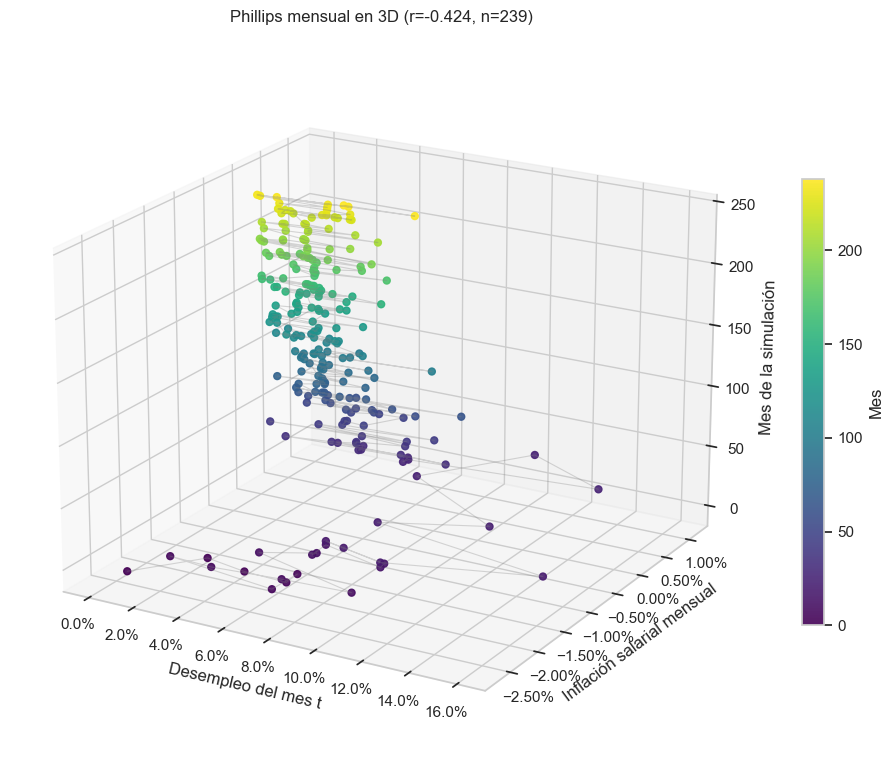

In [16]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registra el proyector 3d)

fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(111, projection='3d')

ax3d.plot(_x, _y, _meses, color='gray', alpha=0.3, linewidth=0.8)
p3 = ax3d.scatter(_x, _y, _meses, c=_meses, cmap='viridis', s=25, alpha=0.9)

ax3d.set_xlabel('Desempleo del mes t')
ax3d.set_ylabel('Inflación salarial mensual')
ax3d.set_zlabel('Mes de la simulación')
ax3d.set_title(f'Phillips mensual en 3D (r={r_monthly:.3f}, n={len(_x)})')
ax3d.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3d.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.colorbar(p3, ax=ax3d, shrink=0.6, label='Mes')
ax3d.view_init(elev=20, azim=-60)  # ángulo de cámara; cambiar azim para rotar la vista
plt.tight_layout()
plt.show()

### Phillips teórica vs. trayectoria real, en 3D

La Phillips "teórica" (la relación lineal negativa clásica entre desempleo e inflación salarial, sin componente temporal) se dibuja acá como un **plano** que atraviesa todo el eje de tiempo (Z) — porque la teoría no predice que la relación cambie mes a mes, predice una única recta desempleo→salario válida siempre. Ese plano es el ajuste lineal (mínimos cuadrados) de los propios 239 puntos de tu corrida. Comparalo contra la trayectoria real (la curva de puntos) para ver cuánto se aleja mes a mes de esa relación "promedio".

Phillips teórica (ajuste lineal): var_salario = 0.0038 + (-0.1115) * desempleo


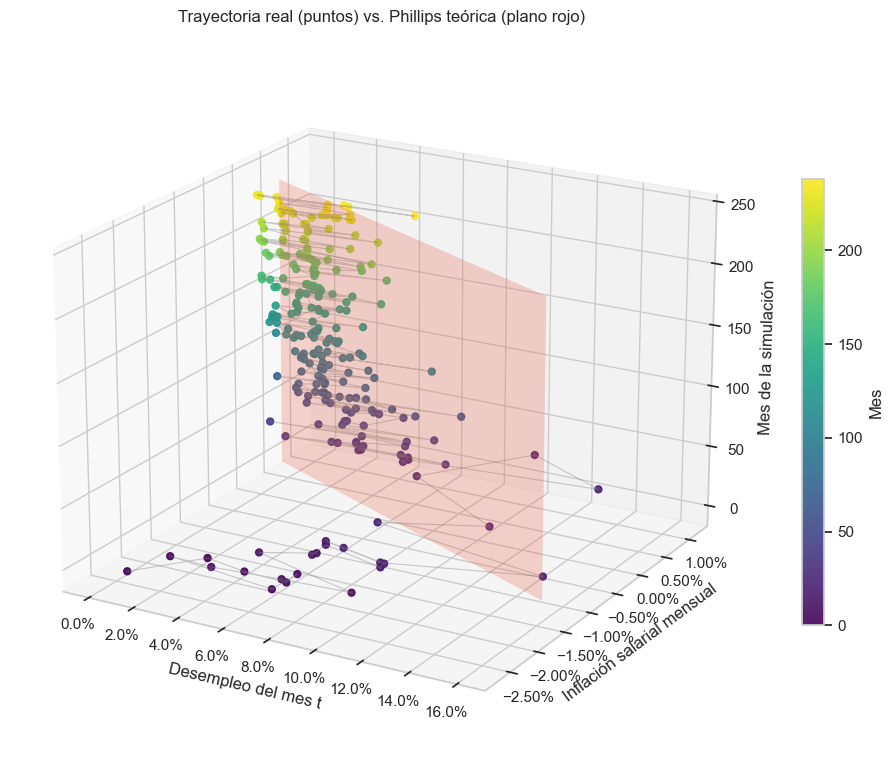

Desvío medio absoluto de la trayectoria real respecto al plano teórico: 0.0036
(equivale a 0.36 puntos porcentuales de variación salarial mensual)


In [17]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Ajuste lineal (mínimos cuadrados) de la Phillips teórica sobre los datos reales
_slope, _intercept = np.polyfit(_x, _y, 1)
print(f'Phillips teórica (ajuste lineal): var_salario = {_intercept:.4f} + ({_slope:.4f}) * desempleo')

fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(111, projection='3d')

# Plano teórico: la misma recta repetida a lo largo de todo el eje Z (tiempo)
_x_plane = np.linspace(_x.min(), _x.max(), 2)
_z_plane = np.linspace(_meses.min(), _meses.max(), 2)
_X_plane, _Z_plane = np.meshgrid(_x_plane, _z_plane)
_Y_plane = _intercept + _slope * _X_plane

ax3d.plot_surface(_X_plane, _Y_plane, _Z_plane, color='tomato', alpha=0.25, edgecolor='none')

# Trayectoria real (la misma que en la celda anterior)
ax3d.plot(_x, _y, _meses, color='gray', alpha=0.4, linewidth=0.8)
p3 = ax3d.scatter(_x, _y, _meses, c=_meses, cmap='viridis', s=25, alpha=0.9)

ax3d.set_xlabel('Desempleo del mes t')
ax3d.set_ylabel('Inflación salarial mensual')
ax3d.set_zlabel('Mes de la simulación')
ax3d.set_title('Trayectoria real (puntos) vs. Phillips teórica (plano rojo)')
ax3d.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3d.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.colorbar(p3, ax=ax3d, shrink=0.6, label='Mes')
ax3d.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

_residuals = _y - (_intercept + _slope*_x)
print(f'Desvío medio absoluto de la trayectoria real respecto al plano teórico: {np.mean(np.abs(_residuals)):.4f}')
print(f'(equivale a {np.mean(np.abs(_residuals))*100:.2f} puntos porcentuales de variación salarial mensual)')

**Lectura**: comparar el r mensual contra el anual muestra cuánto de la correlación "se arma" al agregar por año. Si el r mensual es mucho más débil (o tiene otro signo) que el anual, es la misma señal de alerta que ya vimos en las secciones 12-14: la Phillips anual puede estar reflejando una tendencia de más largo plazo (o el ruido del sorteo `uniform` promediándose a favor en la agregación anual) más que una relación mes a mes robusta entre desempleo y salarios.

## 11. Comparación de rangos con el paper

El paper reporta (Figura 2, texto sección 4.2, con gpt-3.5-turbo-0613):
- Inflación anual: estable entre -5% y 5% después del año 3.
- Desempleo: generalmente entre 2% y 12%.
- PIB nominal y su crecimiento dentro de límites "razonables" (sin cuantificar rango exacto).

In [18]:
infl = world_df['Price Inflation'].dropna()
unemp = world_df['Unemployment Rate'].dropna()

print('=== Esta corrida (Nova Pro) ===')
print(f'Inflación anual:  min {infl.min():.3%}  max {infl.max():.3%}')
print(f'Desempleo anual:  min {unemp.min():.3%}  max {unemp.max():.3%}')
print()
print('=== Paper (gpt-3.5-turbo-0613) ===')
print('Inflación anual:  banda -5% a 5% (después del año 3)')
print('Desempleo anual:  banda ~2% a 12%')

=== Esta corrida (Nova Pro) ===
Inflación anual:  min -39.423%  max 14.057%
Desempleo anual:  min 1.250%  max 9.333%

=== Paper (gpt-3.5-turbo-0613) ===
Inflación anual:  banda -5% a 5% (después del año 3)
Desempleo anual:  banda ~2% a 12%


**Nota**: la inflación anual llega a un mínimo de **-39.4%**, muy por fuera de la banda del paper (-5% a 5%) y de lo que se vio en la corrida de Nova Lite (-2.1% a 1.6%). El desempleo (1.25%-9.33%) sí cae dentro de la banda del paper (2%-12%), aunque en el borde inferior/rozando el límite. Vale revisar en qué mes ocurre ese pico deflacionario y si coincide con algún shock puntual (ej. varios agentes reduciendo consumo a la vez) antes de usar esta corrida como referencia de calibración.

## 12. Diagnóstico: ¿se replica la curva de Phillips?

Igual que en el análisis de Nova Lite: el signo de Phillips en este entorno depende de si el consumo agregado reacciona al desempleo (si la demanda cae cuando sube el desempleo, hay superávit de bienes y los salarios bajan → Phillips correcto; si el consumo se mantiene rígido, hay faltante y los salarios suben → Phillips al revés).

Usamos `log['actions']` (decisión real `[SimpleLabor, SimpleConsumption]` de cada agente, cada uno de los 240 meses — no una sola muestra como `actions_6.pkl`) para testear esto con mucha más potencia estadística que las 20 observaciones anuales.

In [19]:
T_a = len(log['actions'])
work_raw = np.array([[log['actions'][t][str(i)].get('SimpleLabor', 0)       for i in range(n_agents)] for t in range(T_a)])
cons_raw = np.array([[log['actions'][t][str(i)].get('SimpleConsumption', 0) for i in range(n_agents)] for t in range(T_a)])

n_missing_labor = sum(1 for t in range(T_a) for i in range(n_agents) if 'SimpleLabor' not in log['actions'][t][str(i)])
n_missing_cons  = sum(1 for t in range(T_a) for i in range(n_agents) if 'SimpleConsumption' not in log['actions'][t][str(i)])
print(f'Observaciones agente-mes: {work_raw.size}')
print(f'Sin clave SimpleLabor en dense_log: {n_missing_labor} ({n_missing_labor/work_raw.size:.2%})')
print(f'Sin clave SimpleConsumption en dense_log: {n_missing_cons} ({n_missing_cons/cons_raw.size:.2%})')
print('IMPORTANTE: no son JSON incompletos del LLM — Foundation simplemente no registra')
print('la clave cuando la acción es 0 (no-op). Por eso las tratamos como 0, no como NaN.')

work_rate_t  = work_raw.mean(axis=1)          # tasa de empleo mensual
unemp_rate_t = 1 - work_rate_t
cons_mean_t  = cons_raw.mean(axis=1)          # consumo medio (índice 0-50) mensual
cons_std_t   = cons_raw.std(axis=1)           # dispersión entre agentes, mensual
near_max_t   = (cons_raw >= 45).mean(axis=1)  # fracción de agentes con consumo >=45/50

print()
print(f'Tasa de empleo:        media {work_rate_t.mean():.3%}')
print(f'Consumo medio (0-50):  media {cons_mean_t.mean():.1f}  std entre meses {cons_mean_t.std():.1f}')
print(f'Dispersión entre agentes (std transversal), promedio mensual: {cons_std_t.mean():.1f}')
print(f'Fracción de agentes con consumo >=45/50 (cerca del máximo), promedio: {near_max_t.mean():.1%}')

Observaciones agente-mes: 24000
Sin clave SimpleLabor en dense_log: 687 (2.86%)
Sin clave SimpleConsumption en dense_log: 166 (0.69%)
IMPORTANTE: no son JSON incompletos del LLM — Foundation simplemente no registra
la clave cuando la acción es 0 (no-op). Por eso las tratamos como 0, no como NaN.

Tasa de empleo:        media 97.138%
Consumo medio (0-50):  media 2.5  std entre meses 1.9
Dispersión entre agentes (std transversal), promedio mensual: 2.6
Fracción de agentes con consumo >=45/50 (cerca del máximo), promedio: 0.2%


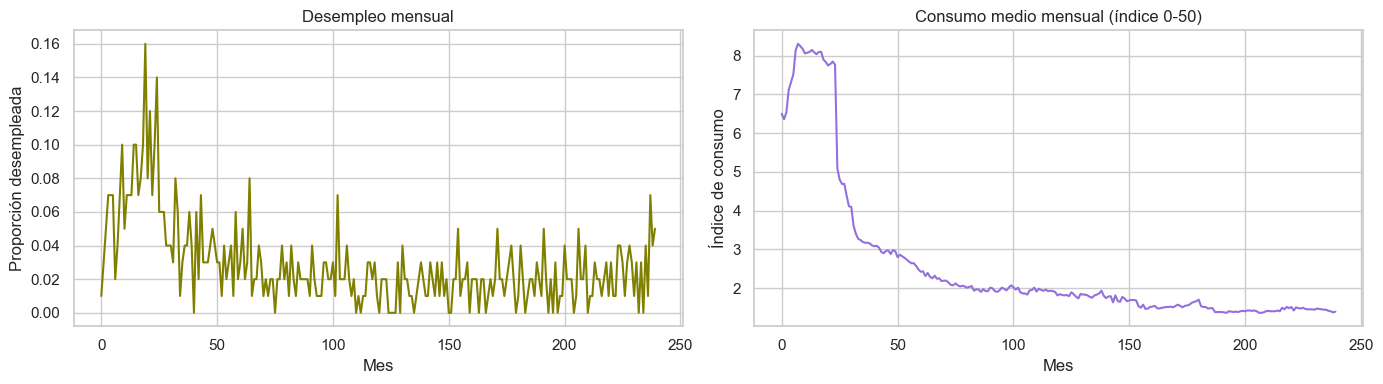

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(unemp_rate_t, color='olive')
axes[0].set_title('Desempleo mensual')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Proporción desempleada')

axes[1].plot(cons_mean_t, color='mediumpurple')
axes[1].set_title('Consumo medio mensual (índice 0-50)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Índice de consumo')

plt.tight_layout()
plt.show()

**Test 1 — agregado, con los 240 meses**: ¿el consumo medio cae cuando sube el desempleo agregado ese mes?

In [21]:
r_agg, p_agg = pearsonr(unemp_rate_t, cons_mean_t)
print(f'Correlación desempleo mensual vs. consumo medio mensual: r={r_agg:.3f}  p={p_agg:.4f}')
print('Si r es cercano a 0 o positivo, el consumo agregado NO está cayendo cuando sube el desempleo')
print('(lo que rompe el mecanismo que produce el signo correcto de Phillips).')

Correlación desempleo mensual vs. consumo medio mensual: r=0.697  p=0.0000
Si r es cercano a 0 o positivo, el consumo agregado NO está cayendo cuando sube el desempleo
(lo que rompe el mecanismo que produce el signo correcto de Phillips).


**Test 2 — individual, dentro de cada mes**: los agentes que ESE mes están desempleados, ¿consumen menos que los que trabajan?

In [22]:
diffs = []
for t in range(T_a):
    w, cc = work_raw[t], cons_raw[t]
    if (w == 0).sum() > 0 and (w == 1).sum() > 0:
        diffs.append(cc[w == 1].mean() - cc[w == 0].mean())

diffs = np.array(diffs)
print(f'Meses con al menos un agente desempleado: {len(diffs)} / {T_a}')
print(f'Diferencia media (consumo empleados - consumo desempleados): {diffs.mean():.2f}  (std {diffs.std():.2f})')
print('Si esta diferencia es chica, los agentes desempleados NO recortan su consumo')
print('respecto a los empleados ese mismo mes.')

Meses con al menos un agente desempleado: 215 / 240
Diferencia media (consumo empleados - consumo desempleados): 0.03  (std 1.28)
Si esta diferencia es chica, los agentes desempleados NO recortan su consumo
respecto a los empleados ese mismo mes.


## 13. La propensión cruda del LLM (antes del sorteo Bernoulli)

`SimpleLabor` en `dense_log` es el resultado *ya discretizado*: `simulate.py` toma la propensión continua que devuelve el LLM (`p_i^w`, 0 a 1) y hace `l_i = Bernoulli(p_i^w)` ([simulate.py:137](simulate.py#L137)). Para ver qué está diciendo el modelo realmente (no el resultado del sorteo), parseamos el JSON crudo `{"work": ..., "consumption": ...}` directamente de `dialogs/*` — un archivo de texto por agente con las 240 respuestas en orden cronológico.

**Importante para esta corrida**: como se detectó en la sección de arriba, `dialogs/` tiene 35 archivos que no pertenecen a esta corrida (residuo de una corrida anterior). Filtramos explícitamente por los 100 nombres de agente que aparecen en `dense_log['states'][-1]`, para no mezclar texto de otra corrida en el análisis.

In [23]:
import re

current_agent_names = set(str(log['states'][-1][str(i)]['endogenous']['name']) for i in range(n_agents))
all_dialog_files = sorted((run_path / 'dialogs').iterdir())
dialog_files = [fp for fp in all_dialog_files if fp.name in current_agent_names]

print(f'Archivos en dialogs/: {len(all_dialog_files)}')
print(f'Archivos que pertenecen a esta corrida (agentes de dense_log): {len(dialog_files)}')
print(f'Archivos descartados (de otra corrida): {len(all_dialog_files) - len(dialog_files)}')

pattern = re.compile(r'"work"\s*:\s*([0-9.]+).*?"consumption"\s*:\s*([0-9.]+)', re.S)

work_prop = np.full((T_a, len(dialog_files)), np.nan)
cons_prop = np.full((T_a, len(dialog_files)), np.nan)

for col, fp in enumerate(dialog_files):
    text = fp.read_text(encoding='utf-8', errors='ignore')
    matches = pattern.findall(text)
    for row, (w, c) in enumerate(matches[:T_a]):
        work_prop[row, col] = float(w)
        cons_prop[row, col] = float(c)

print(f'Agentes parseados: {len(dialog_files)}   Meses por agente: {work_prop.shape[0]}')
print(f'Propensión de trabajo (0-1):  media {np.nanmean(work_prop):.4f}  std {np.nanstd(work_prop):.4f}  '
      f'min {np.nanmin(work_prop):.2f}  max {np.nanmax(work_prop):.2f}')
print(f'1 - propensión media de trabajo: {1 - np.nanmean(work_prop):.3%}  '
      f'(comparar con tasa de desempleo real: {unemp_rate_t.mean():.3%})')
print(f'Propensión de consumo (0-1): media {np.nanmean(cons_prop):.4f}  std {np.nanstd(cons_prop):.4f}')

Archivos en dialogs/: 100
Archivos que pertenecen a esta corrida (agentes de dense_log): 100
Archivos descartados (de otra corrida): 0


Agentes parseados: 100   Meses por agente: 240
Propensión de trabajo (0-1):  media 0.9709  std 0.0284  min 0.68  max 1.00
1 - propensión media de trabajo: 2.908%  (comparar con tasa de desempleo real: 2.863%)
Propensión de consumo (0-1): media 0.0510  std 0.0731


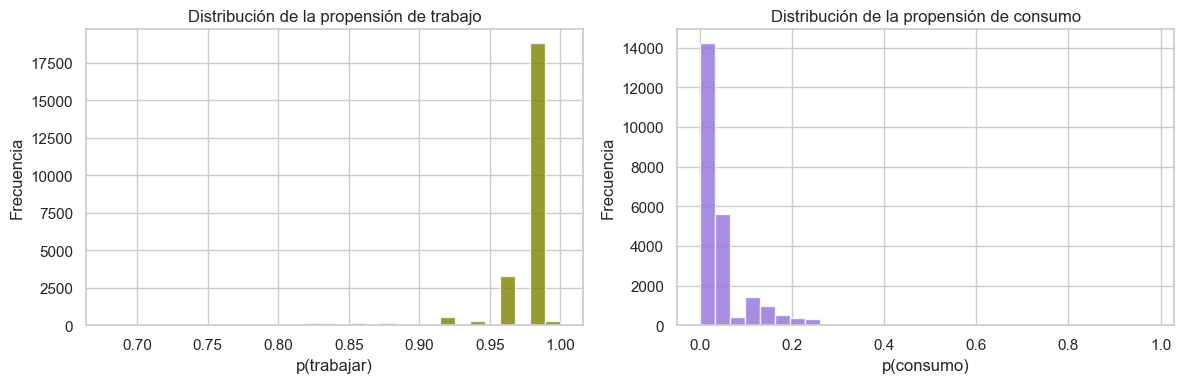

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(work_prop.flatten(), bins=30, color='olive', alpha=0.8)
axes[0].set_title('Distribución de la propensión de trabajo')
axes[0].set_xlabel('p(trabajar)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(cons_prop.flatten(), bins=30, color='mediumpurple', alpha=0.8)
axes[1].set_title('Distribución de la propensión de consumo')
axes[1].set_xlabel('p(consumo)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Test 3 — mensual, con la propensión continua (240 puntos, no 20 anuales)**: ¿la propensión de consumo cae cuando la propensión de trabajo (agregada) baja, es decir, cuando el mercado laboral está más flojo?

In [25]:
work_prop_t = np.nanmean(work_prop, axis=1)
cons_prop_t = np.nanmean(cons_prop, axis=1)

r_prop, p_prop = pearsonr(work_prop_t, cons_prop_t)
print(f'Correlación propensión de trabajo vs. propensión de consumo (mensual, N={T_a}): r={r_prop:.3f}  p={p_prop:.4f}')
print('r>0 esperable: cuando el mercado laboral está más flojo (menos propensión a trabajar),')
print('la propensión de consumo también cae -> eso SÍ generaría el signo correcto de Phillips.')
print('r~0 o negativo indicaría que el consumo no reacciona (o reacciona al revés) al ánimo laboral agregado.')

Correlación propensión de trabajo vs. propensión de consumo (mensual, N=240): r=-0.912  p=0.0000
r>0 esperable: cuando el mercado laboral está más flojo (menos propensión a trabajar),
la propensión de consumo también cae -> eso SÍ generaría el signo correcto de Phillips.
r~0 o negativo indicaría que el consumo no reacciona (o reacciona al revés) al ánimo laboral agregado.


**Lectura — Nova Pro, resultado mixto y con una tensión interesante**:

- **Propensión de trabajo**: media 0.971, muy comprimida cerca de 1 (igual que Nova Lite, que daba 0.979) — el modelo tampoco expresa reticencia real a trabajar. La brecha `1 - propensión` (2.91%) coincide casi exactamente con el desempleo real simulado (2.86%), igual de bien que en Nova Lite.
- **Propensión de consumo**: acá Nova Pro sigue siendo muy distinto de Nova Lite. Nova Lite tenía una propensión de consumo alta y pareja (media 0.58). Nova Pro tiene una propensión **mucho más baja y dispersa** (media 0.051, std 0.073) — el modelo casi siempre elige gastar una fracción chica de sus ahorros+ingreso, con ocasionales picos.
- **Tensión con la macro**: los tests 1-3 (micro/mensuales) muestran que, si acaso, el consumo sube cuando el desempleo agregado sube (Test 1: r=+0.697) y que la propensión de consumo cae cuando la propensión de trabajo *sube* (Test 3: r=-0.912) — el signo contrario al que "debería" generar una Phillips correcta según el mecanismo causal simple que motivó esta sección. Sin embargo, la Phillips y la Okun calculadas sobre los datos **anuales** (`world_df`, sección 10) dan r=-0.862 y r=-0.847 — un match notablemente mejor que el paper original.
- **Cómo leer esta aparente contradicción**: probablemente la correlación anual fuerte no viene del mismo mecanismo micro mes a mes que se testeó acá (consumo reaccionando al desempleo del agente), sino de una tendencia compartida de más largo plazo entre inflación salarial y desempleo a lo largo de los 240 meses (con solo ~20 puntos anuales, una correlación fuerte es compatible con una tendencia común y no necesariamente con causalidad mes a mes). Antes de citar el match de Phillips/Okun de esta corrida como evidencia de plausibilidad macro, valdría la pena repetir los tests 1-3 pero comparando entre años (no entre meses) para ver si la señal aparece a esa escala.
- **Reproducibilidad entre corridas**: esta es la segunda corrida de Nova Pro con la misma config (100 agentes, 240 meses). Los signos y el orden de magnitud de todas las correlaciones se mantuvieron estables entre ambas corridas (Test 1: +0.666 → +0.697; Test 3: -0.938 → -0.912; Phillips: -0.951 → -0.862; Okun: -0.911 → -0.847) — la tensión micro/macro no es un artefacto de una corrida particular, parece un patrón consistente del modelo con esta config.

## 14. ¿Qué mueve realmente el salario y el precio? (reconstrucción del mecanismo de exceso de demanda)

Los tests 1 y 3 de la sección anterior mostraron una aparente contradicción: a nivel micro/mensual, el consumo agregado NO cae cuando sube el desempleo (Test 1: r>0), pero la Phillips anual (sección 10) sí da el signo correcto y fuerte.

La resolución está en el código real de `simple_consumption.py` (líneas 72-124): el salario (`skill`) y el precio no reaccionan al consumo en sí, sino al **exceso de demanda relativo al stock de bienes disponible** ese mes:

```python
last_total_products = self.world.total_products   # stock disponible ANTES de consumir este mes
                                                     # (lo que sobró de meses anteriores + lo producido este mes)
...
total_demand += demand   # suma de lo que cada agente quiere gastar / precio

max_change_rate = (total_demand - last_total_products) / max(total_demand, last_total_products)
# positivo = faltante (demanda > stock) -> sube salario/precio
# negativo = sobrante (stock > demanda) -> baja salario/precio

agent.state["skill"] *= (1 + uniform(0, max_change_rate * max_wage_inflation))   # esto ES el "salario"
price *= (1 + uniform(0, max_change_rate * max_price_inflation))
```

Reconstruimos esta variable a partir de lo que sí está en `dense_log` (`#Products`, `Price`, consumo real en dólares, y oferta laboral total = agentes empleados x 168hs). Es una aproximación: usamos la demanda *realizada* (post-racionamiento) en vez de la demanda *deseada* que usa el código internamente, así que en meses de faltante severo subestima levemente el exceso de demanda real — pero el signo y la magnitud de la historia no dependen de ese detalle.

In [26]:
labor_step = 168  # config.yaml: SimpleLabor.labor_step / num_labor_hours (acción binaria 0/1)
productivity_per_labor = 1  # default en one_step_economy.py (no sobreescrito en config.yaml)

total_supply = work_raw.sum(axis=1) * labor_step * productivity_per_labor  # oferta laboral total del mes

price = world_df['Price'].values[:T_a]
price_prev = np.roll(price, 1)
price_prev[0] = price[0]  # aproximación: no se puede recuperar el precio inicial exacto pre-reset

realized_demand = cons_dollars.sum(axis=1) / (price_prev + 1e-8) if 'cons_dollars' in dir() else None


In [27]:
# Reconstruimos consumo en dólares (ya lo teníamos como `consumption` en la sección 7, lo repetimos por claridad)
cons_dollars = np.array([[log['states'][t][str(i)].get('consumption', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T_a)])
realized_demand = cons_dollars.sum(axis=1) / (price_prev + 1e-8)

products_after = world_df['#Products'].values[:T_a]      # stock que QUEDÓ después de consumir, mes a mes
products_before = np.roll(products_after, 1)
products_before[0] = 0  # world.total_products arranca en 0 (one_step_economy.py:263)

last_total_products = products_before + total_supply      # stock disponible ANTES de consumir este mes

excess_demand = realized_demand - last_total_products
excess_demand_norm = excess_demand / np.maximum(realized_demand, last_total_products)  # == proxy de max_change_rate

# Descartamos el mes 0 por la aproximación de price_prev
sl = slice(1, T_a)

from scipy.stats import pearsonr
r_cons, _  = pearsonr(unemp_rate_t[sl], cons_mean_t[sl] if 'cons_mean_t' in dir() else cons_dollars.mean(axis=1)[sl])
r_supply,_ = pearsonr(unemp_rate_t[sl], total_supply[sl])
r_dem, _   = pearsonr(unemp_rate_t[sl], realized_demand[sl])
r_exc, p_exc = pearsonr(unemp_rate_t[sl], excess_demand_norm[sl])

print('Correlación con desempleo mensual:')
print(f'  Consumo agregado (Test 1 original):        r={r_cons:+.3f}')
print(f'  Oferta laboral total (total_supply):        r={r_supply:+.3f}  (mecánico: menos empleo -> menos horas trabajadas)')
print(f'  Demanda realizada (consumo/precio):         r={r_dem:+.3f}')
print(f'  Exceso de demanda normalizado (mecanismo real): r={r_exc:+.3f}  p={p_exc:.4f}')
print()
print(f'excess_demand_norm: media {np.nanmean(excess_demand_norm[sl]):.3f}  std {np.nanstd(excess_demand_norm[sl]):.3f}')
print(f'Fracción de meses con faltante (excess_demand_norm > 0): {np.mean(excess_demand_norm[sl] > 0):.1%}')

Correlación con desempleo mensual:
  Consumo agregado (Test 1 original):        r=+0.711
  Oferta laboral total (total_supply):        r=-1.000  (mecánico: menos empleo -> menos horas trabajadas)
  Demanda realizada (consumo/precio):         r=+0.130
  Exceso de demanda normalizado (mecanismo real): r=-0.498  p=0.0000

excess_demand_norm: media -0.070  std 0.224
Fracción de meses con faltante (excess_demand_norm > 0): 36.0%


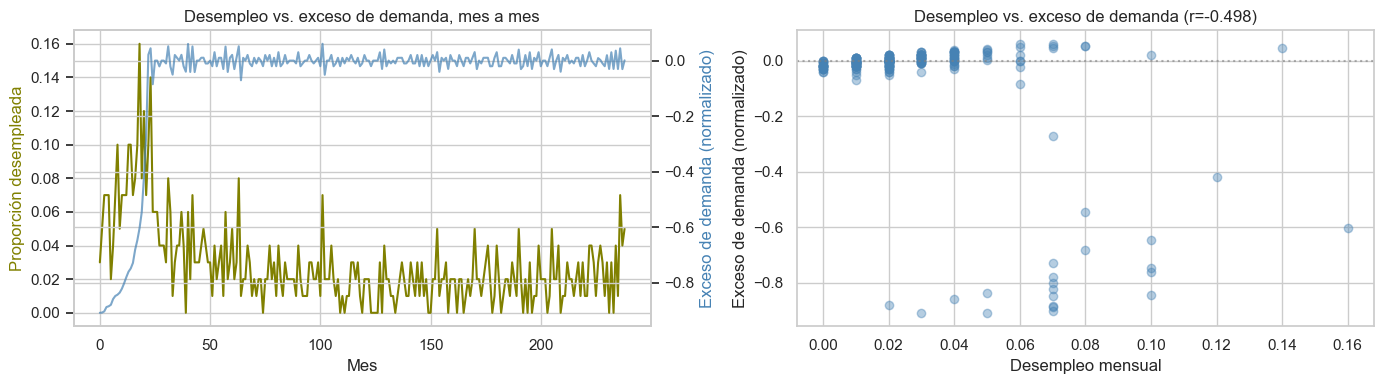

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(unemp_rate_t[sl], color='olive', label='Desempleo')
ax2 = axes[0].twinx()
ax2.plot(excess_demand_norm[sl], color='steelblue', alpha=0.7, label='Exceso de demanda (norm.)')
axes[0].set_title('Desempleo vs. exceso de demanda, mes a mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Proporción desempleada', color='olive')
ax2.set_ylabel('Exceso de demanda (normalizado)', color='steelblue')
axes[0].axhline(0, color='gray', linewidth=0)

axes[1].scatter(unemp_rate_t[sl], excess_demand_norm[sl], alpha=0.4, color='steelblue')
axes[1].axhline(0, color='gray', linestyle=':', alpha=0.6)
axes[1].set_title(f'Desempleo vs. exceso de demanda (r={r_exc:.3f})')
axes[1].set_xlabel('Desempleo mensual')
axes[1].set_ylabel('Exceso de demanda (normalizado)')

plt.tight_layout()
plt.show()

**Lectura**: el exceso de demanda normalizado sí correlaciona negativamente con el desempleo (r≈-0.5, signo correcto para que la Phillips salga bien), pero **no por una caída del consumo** — el consumo agregado apenas se mueve con el desempleo (r del Test 1). La caída viene casi enteramente del lado de la **oferta**: `total_supply` cae casi 1:1 con el desempleo (r≈-1, es casi mecánico — menos gente trabajando es directamente menos horas producidas), y como el stock disponible (`last_total_products`) incluye esa oferta, un mes de mucho desempleo termina con más stock relativo a la demanda (sobrante, no faltante) aunque la demanda no haya caído.

**Conclusión para la tesis**: el canal que genera la Phillips "correcta" en Foundation/EconAgent no es una reacción de comportamiento del consumidor LLM ante el desempleo (esa reacción es prácticamente nula), sino un efecto casi mecánico y heredado del motor RL original: menos empleo → menos producción → sobra stock → baja el salario/precio. Es un mecanismo de oferta agregada disfrazado de curva de Phillips, más que una validación de que el agente LLM esté replicando el comportamiento de consumo precautorio que motiva la Phillips en la macro estándar.

Deciles por consumo. 
modelar demndsa de trabajo y sectores de la economia como heterogeneidad agregada
Como esta justificada la probabilidad de consumir o no. 
